# DQN for Ms Pacman

A variant of DQN with small enough Q network so that it can learn Ms. Pacman in reasonable time.

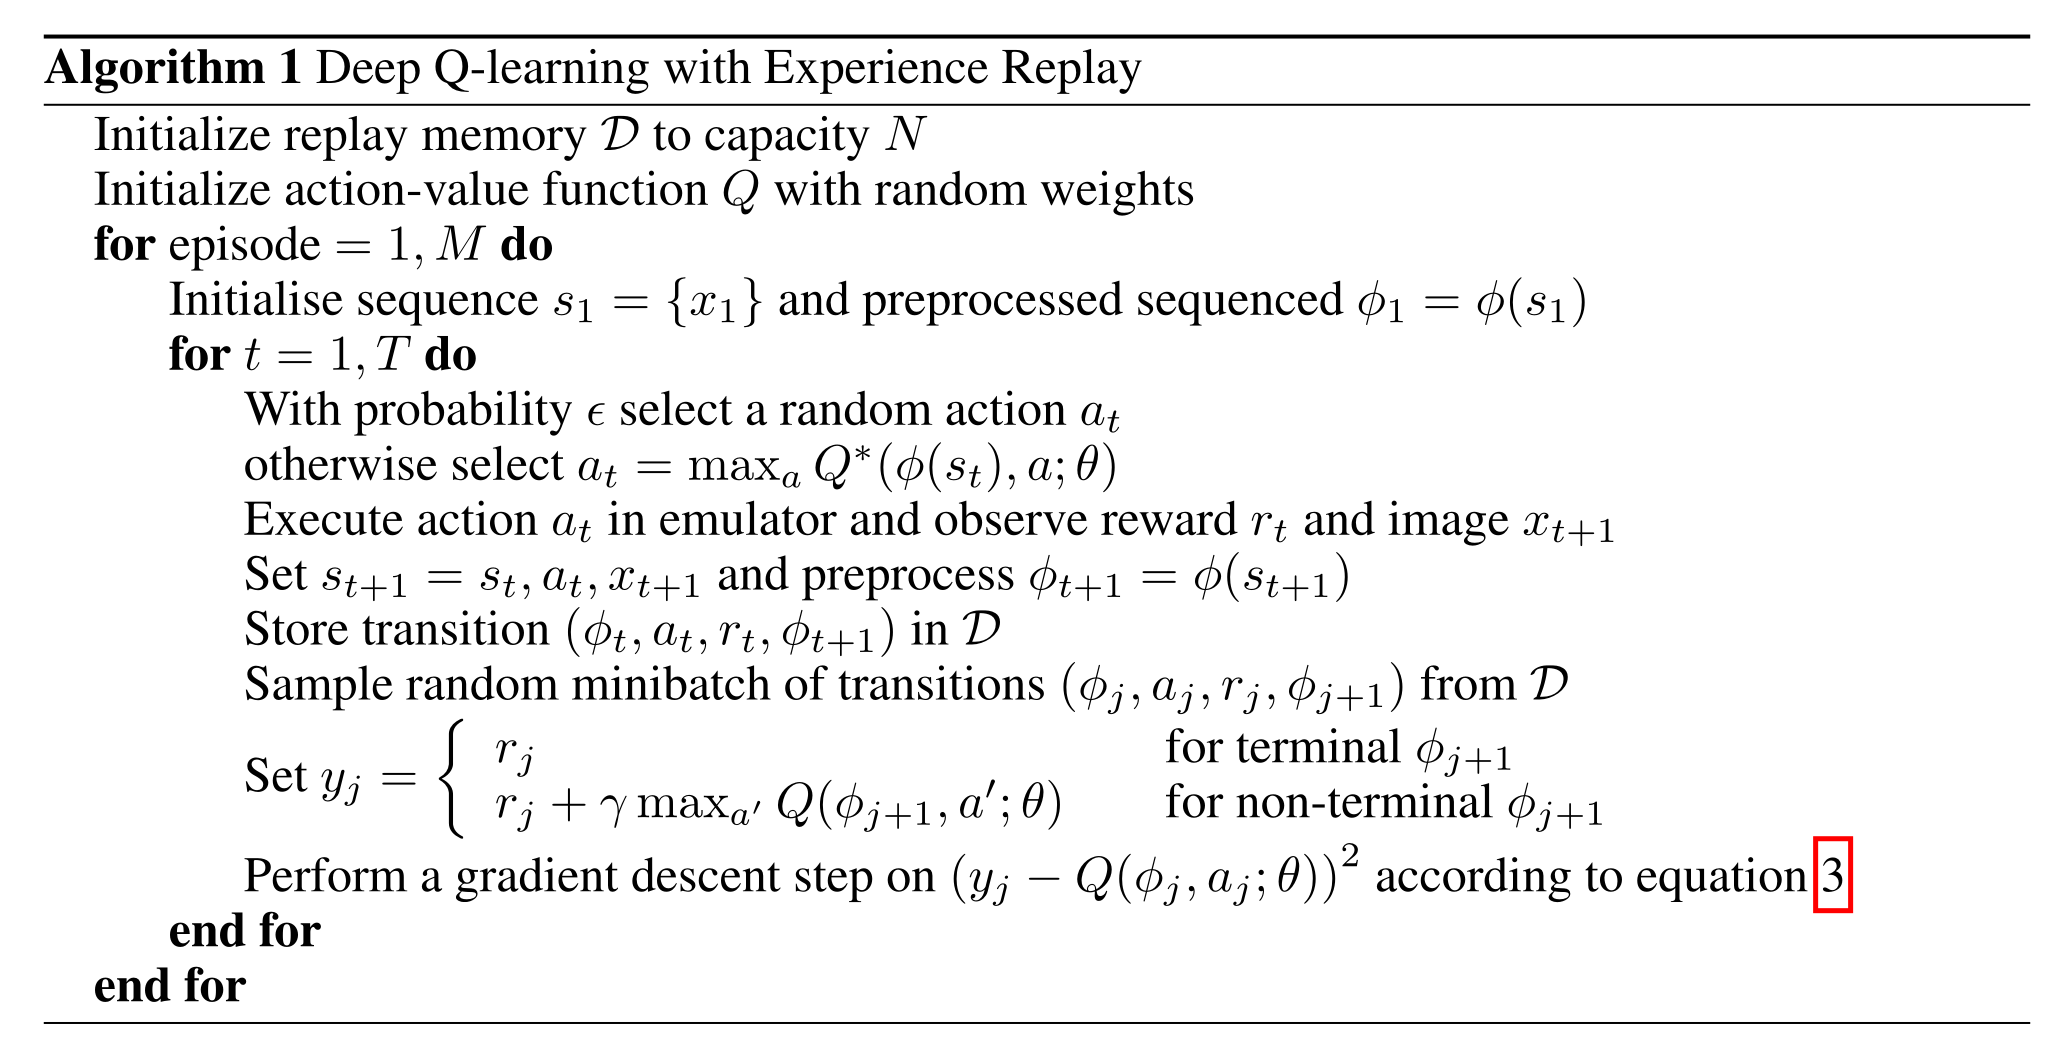

In [1]:
import numpy as np
import torch
import torch.nn as nn
import copy

import gymnasium as gym
import ale_py
gym.register_envs(ale_py)
import matplotlib.pyplot as plt

from torch.utils.tensorboard import SummaryWriter

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


(4, 84, 84)


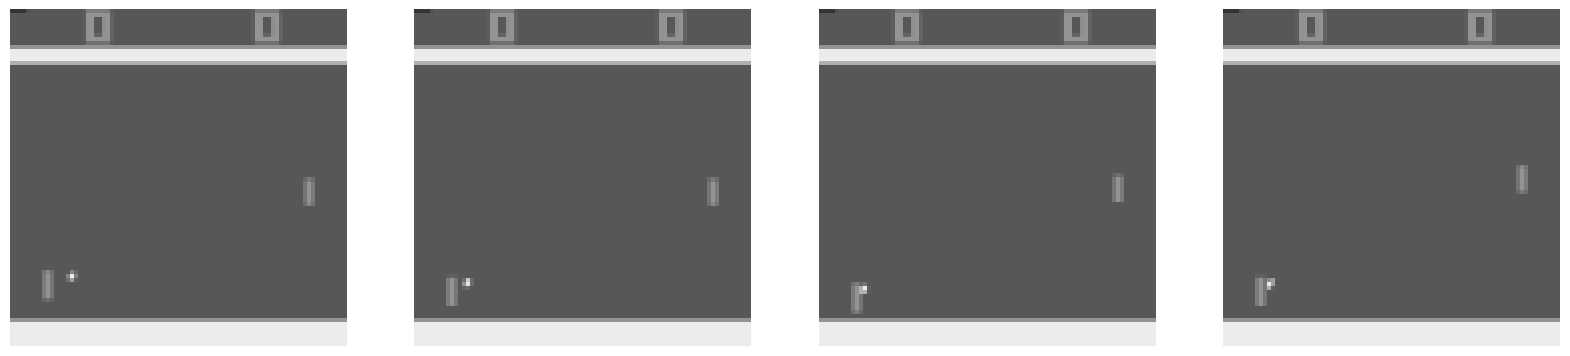

In [2]:
stack_size = 4

env = gym.make("ALE/Pong-v5", frameskip=1) # ALE/MsPacman-v5
env = gym.wrappers.AtariPreprocessing(env, frame_skip=4)
env = gym.wrappers.FrameStackObservation(env, stack_size=stack_size)

obs, info = env.reset()
for i in range(30):
    obs, _, _, _, _ = env.step(env.action_space.sample())

fig = plt.figure(figsize=(20, 30))
for i in range(stack_size):
    ax = plt.subplot(1, stack_size, i+1)
    ax.axis('off')
    plt.imshow(obs[i,:,:], cmap="gray", vmin=0, vmax=255)

print(obs.shape)

del obs, info

In [3]:
n_actions = env.action_space.n # 9 for Ms Pacman

class QNetwork(nn.Module):
    def __init__(self,
                 out_channels_conv2d_1=16,
                 out_channels_conv2d_2=32,
                 out_features_fc=256, 
                 n_actions=n_actions):
        super().__init__()

        self.n_actions = n_actions

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=4, out_channels=16, kernel_size=8, stride=4), # treating the 4 images as channel dimension
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(in_features=32*9*9, out_features=out_features_fc),
            nn.ReLU(),
            nn.Linear(in_features=out_features_fc, out_features=self.n_actions)
        )
    
    # @torch.compile(dynamic=True) # TypeError: cannot determine truth value of Relational: 4 < 4*s20
    def forward(self, obs):
        had_batch_dim = obs.dim() == 4 # 1 batch, 3 image
        if not had_batch_dim:
            obs = obs.unsqueeze(0) # add batch dimension
        logits = self.net(obs) # will have a batch dimension
        if not had_batch_dim:
            logits = logits.squeeze(0)
        return logits
    
    def epsgreedy(self, obs, eps=0.0):
        """epsilon greedy sampling"""
        if torch.rand(1) < eps: # TODO could try to preallocate a long random vector and access it, non-randomness for torch.compile
            # A = np.random.choice(self.n_actions)
            A = torch.multinomial(torch.arange(self.n_actions, dtype=torch.float), 1, replacement=False).to(dtype=torch.int32)
        else:
            A = torch.argmax(self.forward(obs)).to(dtype=torch.int32) # TODO make batch compatible
        return A

In [4]:
# Initialize replay memory D to capacity N
# Initialize action-value function Q with random weights
# for episode = 1, M do (count total number of env.steps as opposed to episodes)
# 	Initialize sequence s_1 = {x_1} and preprocessed sequence phi_1 = phi(s_1)
# 	for t = 1, T do (I guess this is a loop over the episode? Don't need it if we count total env.steps)
# 		With probability eps select a random action a_t
# 		otherwise select a_t = max_a Q*(phi(s_t), a; \theta)
# 		Execute action a_t in emulator and observe reward r_t and image x_{t+1}
# 		Set s_{t+1} = s_t, a_t, x_{t+1} and preprocess \phi_{t+1} = \phi(s_{t+1})
# 		Store transition (\phi_t, a_t, r_t, \phi_{t+1}) in D
# 		Sample random minibatch of transitions (\phi_j, a_j, r_j, \phi_{j+1}) from D
# 		Set y_j = r_j for terminal \phi_{j+1}, y_j = r_j + gamma * max_a' Q(\phi_{j+1}, a'; \theta) for non-terminal \phi_{j+1}
# 		Perform a gradient descent step on (y_j - Q(\phi_j, a_j; \theta))^2
# 	end for
# end for

In [5]:
class ReplayBuffer:
    def __init__(self, N=100000):

        self.fields = [
            torch.empty(size=(N, 4, 84, 84), dtype=torch.uint8), # S
            torch.empty(size=(N,), dtype=torch.int32), # A
            torch.empty(size=(N,), dtype=torch.float32), # R
            torch.empty(size=(N, 4, 84, 84), dtype=torch.uint8), # S_prime
            torch.empty(size=(N,), dtype=torch.bool), # terminated
            torch.empty(size=(N,), dtype=torch.bool) # truncated
        ]

        self.N = N
        self.pos = 0 # position at which to write to the buffer, could also use self.n_inventory % self.N
        self.n_inventory = 0 # how many items the buffer currently holds

    def add_and_cast(self, tup):
        for i, item in enumerate(tup):
            if isinstance(item, torch.Tensor): # A may be a tensor
                item = item.detach().clone().requires_grad_(False).to(dtype=self.fields[i].dtype)
            else:
                item = torch.tensor(item, requires_grad=False, dtype=self.fields[i].dtype)
            assert self.fields[i].shape[1:] == item.squeeze(0).shape # compare non-batch dims
            self.fields[i][self.pos, ...] = item

        self.pos = ((self.pos + 1) % self.N)
        self.n_inventory = min(self.n_inventory + 1, self.N)

    def sample_and_cast(self,  mini_batch_size=32):
        assert self.n_inventory >= mini_batch_size
        ixs = np.random.default_rng().choice(self.n_inventory, size=mini_batch_size, replace=False)
        return tuple([f[ixs, ...].to(dtype=torch.float32) if f.dtype == torch.uint8 else f[ixs, ...] for f in self.fields]) # TODO what about advanced indexing (copy vs view?)

In [6]:
class DQN():
    def __init__(self,
                 env,
                 alpha = 0.00025,
                 gamma = 0.99,
                 eps_function = lambda n_frames: 0.1 if n_frames > 1e6 else 1 - n_frames/1e6 * 0.9,
                 model=QNetwork(),
                 buffer_size=1000000):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.eps_function = eps_function

        self.model = model
        self.target_network = copy.deepcopy(model)
        for p in self.target_network.parameters():
            p.requires_grad = False

        self.buffer_size = buffer_size
        self.buffer = ReplayBuffer(N=self.buffer_size)

        self.optimizer = torch.optim.Adam(params=self.model.parameters(), lr=self.alpha)

        self.evaluation_rewards = []

        self.writer = SummaryWriter(log_dir="../runs/", filename_suffix="_DQN")
        self.evaluation_epoch_counter = 0

    def train(self,
              n_steps,
              mini_batch_size=32,
              C=10000, # target network update frequency
              evaluation_period=50_000,
              evaluation_steps=10_000
              ):

        # Initialize buffer with at least mini_batch_size many (random) items # TODO this may not be necessary if train() has already been called and buffer contains something
        for i in range(mini_batch_size):
            S, info = self.env.reset()
            A = self.env.action_space.sample() # TODO step counting is off by mini_batch_size
            S_prime, R, terminated, truncated, info = self.env.step(A)
            self.buffer.add_and_cast((S, A, R, S_prime, terminated, truncated))

        S, info = self.env.reset()
        done = False

        for istep in range(1, n_steps+1):
            
            # With probability eps select a random action a_t
            # otherwise select a_t = max_a Q*(phi(s_t), a; \theta)
            with torch.no_grad():
                A = self.model.epsgreedy(torch.tensor(S, requires_grad=False, dtype=torch.float32).div_(255.0), self.eps_function(istep)) # TODO potentially buffer the forward call

            # Execute action a_t in emulator and observe reward r_t and image x_{t+1}
            S_prime, R, terminated, truncated, info = self.env.step(A)
            done = terminated or truncated
            
            # Set s_{t+1} = s_t, a_t, x_{t+1} and preprocess \phi_{t+1} = \phi(s_{t+1})
            # Store transition (\phi_t, a_t, r_t, \phi_{t+1}) in D
            self.buffer.add_and_cast((S, A, R, S_prime, terminated, truncated))

            # Sample random minibatch of transitions (\phi_j, a_j, r_j, \phi_{j+1}) from D
            mb_S, mb_A, mb_R, mb_S_prime, mb_terminated, mb_truncated = self.buffer.sample_and_cast(mini_batch_size)
            
            # Set y_j = r_j for terminal \phi_{j+1}, 
            # y_j = r_j + gamma * max_a' Q(\phi_{j+1}, a'; \theta) for non-terminal \phi_{j+1}
            with torch.no_grad():
                mb_terminal = torch.logical_or(mb_terminated, mb_truncated) # TODO TBD whether this is the definition of terminal
                mb_ys = mb_R  + (self.gamma * torch.max(self.target_network(mb_S_prime.div_(255.0)), dim=1).values) * (1-1*mb_terminal)


            # Perform a gradient descent step on (y_j - Q(\phi_j, a_j; \theta))^2
            qs = self.model(mb_S.div_(255.0))
            loss = torch.mean((mb_ys - qs[torch.arange(mini_batch_size), mb_A])**2) # torch.gather()?

            # self.optimizer.zero_grad()
            for param in self.model.parameters():
                param.grad = None
            loss.backward()
            self.optimizer.step()

            if istep % C == 0:
                self.target_network = copy.deepcopy(self.model)
                for param in self.target_network.parameters():
                    param.requires_grad = False
            
            if istep % evaluation_period == 0:
                print(f"Step {istep} of {n_steps}")
                epoch_evaluation_rewards = self.evaluate(evaluation_steps=evaluation_steps)
                self.evaluation_rewards.append(epoch_evaluation_rewards)
                print(f"Average evaluation rewards: {np.mean(epoch_evaluation_rewards)}")

            if done:
                S, info = self.env.reset()
                done = False
            else:
                S = S_prime
            
            self.writer.add_scalar('Training/Mini-batch loss', loss.detach().item(), istep)
            
    
    def evaluate(self, eps=0.05, evaluation_steps=10_000):
        env = copy.deepcopy(self.env)
        S, _ = env.reset()
        done = False
        evaluation_rewards = [0] # start with something in it already: return something, even if no episode is completed

        for istep in range(1, evaluation_steps+1):
            
            with torch.no_grad():
                A = self.model.epsgreedy(torch.tensor(S, requires_grad=False, dtype=torch.float32).div_(255.0), eps=eps)
            
            S_prime, R, terminated, truncated, _ = env.step(A)
            evaluation_rewards[-1] += R
            done = terminated or truncated

            if done:
                S, _ = env.reset()
                done = False
                evaluation_rewards.append(0)
            else:
                S = S_prime
        
        self.writer.add_scalar('Evaluation/Average evaluation rewards:', np.mean(evaluation_rewards), self.evaluation_epoch_counter)
        self.evaluation_epoch_counter += 1

        return evaluation_rewards

In [ ]:
dqn = DQN(env=env, buffer_size=250_000) # could only use 400_000 with 32 GB ram
dqn.train(1_000_000, mini_batch_size=32, evaluation_period=50_000, evaluation_steps=10_000) # 1_000_000, 32, 50_000, 10_000

In [ ]:
l = []
for innerl in dqn.evaluation_rewards:
    l.extend(innerl)

plt.plot(np.convolve(l, np.ones(100)/100, 'valid'))